# Introduction to Classification with Logistic Regression, Project 1 Discussion

When we introduced **supervised learning**, we discussed two main tasks: regression (predicting values) and classification (predicting classes).

Classifiers can be categorized as **discriminative** or **generative** classifiers. And sometimes a hybrid version **probabilistic discriminative** classifier, such as the logistic regression algorithm.

* A **discriminative** approach for classification is one in which we partition the feature space into regions for each class. Then, when we have a test point, we evaluate in which region it landed on and classify it accordingly.

* A **generative** approach for classification is one in which we estimate the parameters for distributions that generate the data for each class using Bayesian principles. When we have a test point, we can compute the posterior probability of that point belonging to each class and assign the point to the class with the highest posterior probability.

___

# Logistic Regression, also called *Logit* Regression or Logistic Discrimination

*Note that, despite of its name, logistic regression is a model for classification, not regression.*

The **logistic discriminant** is a linear model for binary classification that can be extended to multi-class classification using the one-vs-all approach.

Logistic regression is a **probabilistic discriminative classifier**.

In logistic logistic discrimination, we do not model the class-conditional densities, $p(x|C_i)$, but rather their ratio. Let us assume we are working with a two-class problem and assume that the log likelihood ratio (or **odds ratio**) is linear:

\begin{align*}
\log\frac{P(x|C_1)}{P(x|C_2)} = \mathbf{w}^Tx + b
\end{align*}

* This is only true, if the classes are Gaussian-distributed!

* But logistic discrimination has a wider scope of applicability; for example, $x$ may be composed of discrete attributes or may be a mixture of continuous and discrete attributes. Using Bayes’ rule, we have:

\begin{align*}
\operatorname{logit} P(C_1|x) &=\log \frac{P(C_1|x)}{1-P(C_1|x)}\\
&= \log \frac{P(x|C_1)}{P(x|C_2)} + \log \frac{P(C_1)}{P(C_2)} \\
&= \mathbf{w}^Tx + w_0
\end{align*}

where $w_0 = b + \log \frac{P(C_1)}{P(C_2)}$.

Rearranging terms, we get the probabilistic classification:

\begin{align*}
y = P(C_1|x) = \frac{1}{1+\exp\left(-(\mathbf{w}^Tx+w_0)\right)}
\end{align*}

This is the sigmoid function:

\begin{align*}
\phi(z) = \frac{1}{1+\exp(-z)}
\end{align*}

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('bmh')

In [ ]:
z = np.linspace(-8,8,100)

plt.figure(figsize=(7,5))
plt.plot(z, 1/(1+np.exp(-z)))
plt.plot(z, [0.5]*len(z),'--')
plt.xlabel('$z$',size=20); plt.ylabel('$\phi(z)$',size=20);
plt.title('Sigmoid Function',size=15);

* We can see that $\phi(z)\rightarrow 1$ as $z\rightarrow\infty$, since $\exp(-z)$ becomes very small for large values of $z$.

* Similarly, $\phi(z)\rightarrow 0$ as $z\rightarrow -\infty$ as the result of an increasingly large denominator. 

Thus, we conclude that this sigmoid function takes real number values as input and transforms them to values in the range $[0, 1]$ with an intercept at $\phi(z)=0.5$.

This is the same as using a sigmoid function as the **activation function** in the perceptron diagram.

Thus the output of the sigmoid function is then interpreted as the probability of particular sample belonging to $C_1$, given its features $x$ parameterized by the weights $w$. 

* For example, if we compute $\phi(z)=0.8$ for a particular sample, it means that the chance that this sample is in $C_1$ is 80%. 

The predicted probability can then simply be converted into a binary outcome via a quantizer (unit step function):

\begin{align*}
\hat{t} = y &= \begin{cases}1, & \phi(z)\geq 0.5\\ 0, & \text{otherwise}\end{cases}\\
&=\begin{cases}1, & \phi(\mathbf{w}^Tx+w_0)\geq 0.5\\ 0, & \text{otherwise}\end{cases}
\end{align*}

or,

\begin{align*}
\hat{t} = y &= \begin{cases}1, & z\geq 0\\ 0, & z<0\end{cases} \\
&= \begin{cases}1, & \mathbf{w}^Tx+w_0\geq 0\\ 0, & \mathbf{w}^Tx+w_0<0\end{cases}
\end{align*}

## The Objective Function

Let $\{(x_i,t_i)\}_{i=1}^N$ be the set of input samples and its class labels, where $t_i\in\{0,1\}$. Assuming the data samples are i.i.d., we can build the observed data likelihood:

\begin{align*}
\mathcal{L}^0 = \prod_{i=1}^N P(y_i|x_i; \mathbf{w}) = \phi(z_i)^{t_i}(1-\phi(z_i))^{1-t_i}
\end{align*}

We can apply the "trick" (log-likelihood) to build the data likelihood":

\begin{align*}
\mathcal{L} = \sum_{i=1}^N t_i\log\phi(z_i) +(1-t_i)\log(1-\phi(z_i))
\end{align*}

where $\phi(z) = \frac{1}{1+\exp(-z)}$ and $z_i = \mathbf{w}^Tx_i+w_0$.

We want to maximize this likelihood to the data, or we can also write it as a minimization optimization:

\begin{align*}
J(\mathbf{w},w_0) = \sum_{i=1}^N - t_i\log\phi(z_i) - (1-t_i)\log(1-\phi(z_i))
\end{align*}

This objective function is also known as **cross-entropy**.

In [ ]:
z = np.linspace(-2,2,100)

phi = lambda z: 1/(1+np.exp(-z))

plt.figure(figsize=(7,5))
plt.plot(phi(z), -np.log(phi(z)),label='when $t=1$')
plt.plot(phi(z), -np.log(1-phi(z)),'--',label='when $t=0$')
plt.legend(fontsize=15); plt.xlabel('$\phi(z)$',size=20)
plt.ylabel('$J(\mathbf{w})$',size=20);

In [ ]:
plt.plot(z, -np.log(phi(z))-np.log(1-phi(z)),'--',label='$J(w,w_0)$')
plt.legend(fontsize=20);

We can see that the cost approaches 0 if we correctly predict that a sample belongs to class 1. Similarly, we can see on the y axis that the cost also approaches 0 if we correctly predict class 0. However, if the prediction is wrong, the cost goes towards infinity: we penalize wrong predictions with an increasingly larger cost.

As we do not have the global *picture* of what the objective function, $J(\mathbf{w})$, we apply a search method to navigate through the objective function to find the *local optima* starting from an initial value, namely, **gradient descent**.

\begin{align*}
\mathbf{w}^{(t+1)} \longleftarrow \mathbf{w}^{(t)} - \eta \frac{\partial J(\mathbf{w})}{\partial \mathbf{w}^{(t)}}
\end{align*}

\begin{align*}
\mathbf{w_0}^{(t+1)} \longleftarrow \mathbf{w_0}^{(t)} - \eta \frac{\partial J(\mathbf{w})}{\partial \mathbf{w_0}^{(t)}}
\end{align*}

where $\eta$ is the learning rate (or step size).

\begin{align*}
\frac{\partial J(\mathbf{w})}{\partial \mathbf{w}^{(t)}} =
\sum_{i=1}^N -t_i\frac{1}{\phi(z_i)}\frac{\partial\phi(z_i)}{\partial z_i}\frac{\partial z_i}{\partial\mathbf{w}} -(1-t_i)\frac{1}{1-\phi(z_i)}\left(-\frac{\partial\phi(z_i)}{\partial z_i}\frac{\partial z_i}{\partial\mathbf{w}}\right)
\end{align*}

where $\frac{\partial\phi(z_i)}{\partial z_i} = \phi'(z_i)$ and $\frac{\partial z_i}{\partial\mathbf{w}} = x_i$. Substituting:

\begin{align*}
\frac{\partial J(\mathbf{w})}{\partial \mathbf{w}^{(t)}} &= \sum_{i=1}^N -t_i \frac{\phi'(z_i)}{\phi(z_i)} x_i + (1-t_i)\frac{\phi'(z_i)}{1-\phi(z_i)} x_i \\
&= \sum_{i=1}^N \left(\frac{t_i}{\phi(z_i)} - \frac{1-t_i}{1-\phi(z_i)}\right)\phi'(z_i)x_i
\end{align*}

where $\phi'(z_i)= \phi(z_i)(1-\phi(z_i))$, then applying some substitutions we have:

\begin{align*}
\frac{\partial J(\mathbf{w})}{\partial \mathbf{w}^{(t)}} = \sum_{i=1}^N (t_i - y_i)x_i
\end{align*}

and, similarly,

\begin{align*}
\frac{\partial J(\mathbf{w})}{\partial w_0^{(t)}} = \sum_{i=1}^N (t_i - y_i)
\end{align*}

Finally,

\begin{align*}
\mathbf{w}^{(t+1)} \longleftarrow \mathbf{w}^{(t)} - \eta \sum_{i=1}^N (t_i - y_i)x_i
\end{align*}

\begin{align*}
\mathbf{w_0}^{(t+1)} \longleftarrow \mathbf{w_0}^{(t)} - \eta \sum_{i=1}^N (t_i - y_i)
\end{align*}

**Initialization:** it is best to initialize $\mathbf{w}$ with random values close to 0; generally they are drawn uniformly from the interval $[−0.01, 0.01]$. 

* The reason for this is that if the initial $\mathbf{w}$ are large in magnitude, the weighted sum may also be large and may saturate the sigmoid. 

* If the initial weights are close to 0, the sum will stay in the middle region where the derivative is nonzero and an update can take place. 

* If the weighted sum is large in magnitude (smaller than −5 or larger than +5), the derivative of the sigmoid will be almost 0 and weights will not be updated. 
    * When we stack up a lot of these perceptrons in layers and add a few layers, this "close to 0" gradient will lead to a phenomenon in neural networks known as the **vanishing gradient**.

---

Let's import a classification dataset: the iris dataset.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('bmh')

In [2]:
from sklearn.datasets import load_iris

In [3]:
iris = load_iris(as_frame=False)

In [4]:
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

Datasets loaded by ```sklearn``` generally have a similar disctionary structure, including the following:

* A ```DESCR``` key describing the dataset
* A ```data``` key containing an array with one row per instance and one column per feature
* A ```target``` key containing an array with the labels

In [5]:
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [6]:
iris.data

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [7]:
iris.data.shape, iris.target.shape

((150, 4), (150,))

In [8]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

There are 150 samples, and each sample has 4 features (sepal length, sepal width, petal length and petal width).

In [9]:
np.unique(iris.target, return_counts=True)

(array([0, 1, 2]), array([50, 50, 50]))

In [10]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

Each sample is classified as one of 3 classes: 0 is setosa, 1 is versicolor, and 2 is virginica.

For visualization purposes, let's consider only features **petal length** and **petal width**.

In [11]:
X = iris.data[:,2:]

X.shape

(150, 2)

## Training a Binary Classifier

Let's simplify the problem for now and only try to identify one iris species - for example, the **class setosa**. This "setosa-detector" will be an example of a binary classifier, capable of distinguishing between just two classes, setosa and not-setosa. Let's create the target vectors for this classification task:

In [12]:
t = 1*(iris.target == 0)

In [13]:
t

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

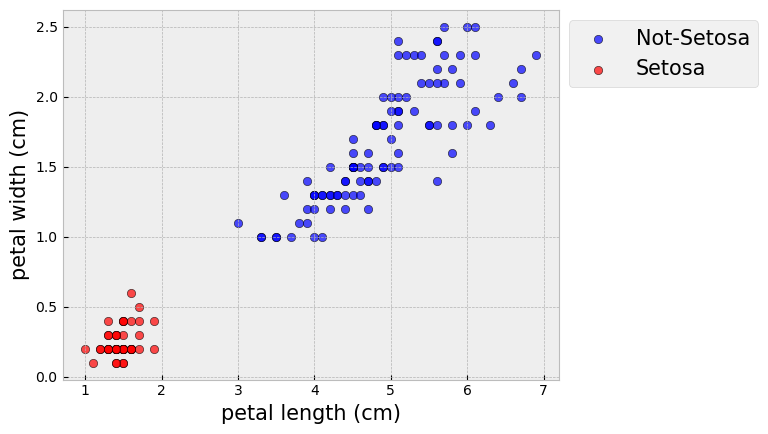

In [14]:
plt.scatter(X[t==0,0], X[t==0,1], c='b', edgecolors='k', alpha=0.7, label='Not-Setosa')
plt.scatter(X[t==1,0], X[t==1,1], c='r', edgecolors='k', alpha=0.7, label='Setosa')
plt.xlabel(iris.feature_names[2], size=15)
plt.ylabel(iris.feature_names[3], size=15)
plt.legend(bbox_to_anchor=(1,1),fontsize=15);

In [16]:
from sklearn.linear_model import LogisticRegression

LogisticRegression?

Note that there exist many different optimization algorithms for solving optimization problems. For minimizing convex loss functions, such as the logistic regression loss, it is recommended to use more advanced approaches than regular stochastic gradient descent (SGD). In fact, scikit-learn implements a whole range of such optimization algorithms, which can be specified via the solver parameter, namely, ```newton-cg``` , ```lbfgs``` , ```liblinear``` , ```sag``` , and ```saga``` . 

While the logistic regression loss is convex, most optimization algorithms should converge to the global loss minimum with ease. However, there are certain advantages of using one algorithm over the other. For instance, in a previous version, ```scikit-learn``` used ```liblinear``` as a default, which cannot handle the multinomial loss and is limited to the OvR scheme for multi-class classification. However, in current version of ```scikit-learn```, the default solver uses ```lbfgs```, which stands for the limited-memory **Broyden-Fletcher-Goldfarb-Shanno (BFGS)** algorithm (https://en.wikipedia.org/wiki/Limited-memory_BFGS) and is more flexible in this regard.

In [17]:
log_reg = LogisticRegression(penalty=None)

In [18]:
log_reg.fit(X, t)

LogisticRegression(penalty=None)

In [19]:
log_reg.intercept_

array([26.5686254])

In [20]:
log_reg.coef_

array([[ -7.1801606, -10.4691716]])

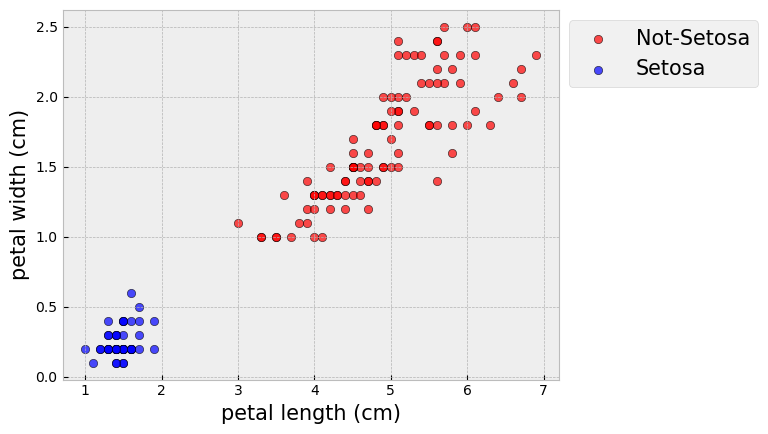

In [21]:
plt.scatter(X[t==0,0], X[t==0,1], c='r', edgecolors='k', alpha=0.7, label='Not-Setosa')
plt.scatter(X[t==1,0], X[t==1,1], c='b', edgecolors='k', alpha=0.7, label='Setosa')
plt.xlabel(iris.feature_names[2], size=15)
plt.ylabel(iris.feature_names[3], size=15)
plt.legend(bbox_to_anchor=(1,1),fontsize=15);

In [22]:
# generate synthetic data in the 2-D feature space

xx, yy = np.meshgrid(np.arange(0, 8, 0.01),
                     np.arange(-1, 3, 0.01))

mesh = np.vstack((xx.ravel(), yy.ravel())).T

xx.shape, yy.shape, mesh.shape

((400, 800), (400, 800), (320000, 2))

In [23]:
# Making predictions


# Sigmoid function as an inline Python function
sigmoid = lambda x: 1/(1+np.exp(-x))


# Probabilistic predictions using mapper function equation
sigmoid(mesh@log_reg.coef_.T + log_reg.intercept_)

array([[1.00000000e+00],
       [1.00000000e+00],
       [1.00000000e+00],
       ...,
       [1.23333248e-27],
       [1.14788169e-27],
       [1.06835131e-27]])

In [24]:
# Probabilistic predictions using sklearn

probs = log_reg.predict_proba(mesh)

probs

array([[0.00000000e+00, 1.00000000e+00],
       [0.00000000e+00, 1.00000000e+00],
       [0.00000000e+00, 1.00000000e+00],
       ...,
       [1.00000000e+00, 1.23333248e-27],
       [1.00000000e+00, 1.14788169e-27],
       [1.00000000e+00, 1.06835131e-27]])

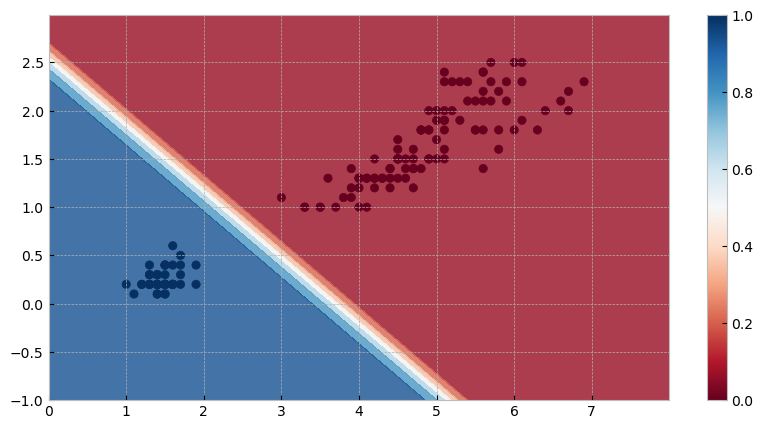

In [25]:
plt.figure(figsize=(10,5))
plt.contourf(xx, yy, probs[:,1].reshape(xx.shape), cmap=plt.cm.RdBu, alpha=.8)
plt.scatter(X[:,0], X[:,1], c=t, cmap=plt.cm.RdBu)
plt.rcParams['axes.grid'] = False #runtime configuration (rc) settings
plt.colorbar();

In [26]:
# Label predictions using sklearn

labels = log_reg.predict(mesh)

labels

array([1, 1, 1, ..., 0, 0, 0])

In [ ]:
plt.figure(figsize=(10,5))
plt.contourf(xx, yy, labels.reshape(xx.shape), cmap=plt.cm.RdBu, alpha=.8)
plt.scatter(X[:,0], X[:,1], c=t, cmap=plt.cm.RdBu)
plt.rcParams['axes.grid'] = False #runtime configuration (rc) settings
plt.colorbar();

---

# Saving ```scikit-learn``` Objects as ```pickle``` files

You should save every model you experiment with so that you can come back easily to any model you want. Make sure you save both the hyperparameters and the trained parameters, as well as the cross-validation scores and perhaps the actual predictions as well. This will allow you to easily compare scores across model types, and compare the types of errors they make. You can easily save Scikit-Learn models by using [Python's ```pickle``` module](https://docs.python.org/3/library/pickle.html) or by using the [```joblib``` library](https://joblib.readthedocs.io/en/latest/), which is more efficient at serializing large NumPy arrays (you can install this library using pip): 

````python
import joblib 
joblib.dump(my_model, 'my_model.pkl') 
# and later... 
my_model_loaded = joblib.load('my_model.pkl')
````

In [27]:
import joblib

joblib.dump(log_reg, 'log_reg_model.pkl')

['log_reg_model.pkl']

In [28]:
model = joblib.load('log_reg_model.pkl')

model.predict([[3,-0.5]])

array([1])

---

## Multiple Classes

Considering the extension of linear discriminants to $K > 2$ classes. We might be tempted be to build a $K$-class discriminant by combining a number of two-class discriminant functions. However, this leads to some serious difficulties.

* Consider the use of $K−1$ classifiers each of which solves a two-class problem of separating points in a particular class $C_k$ from points not in that class. This is known as a **one-versus-all** classifier.

* An alternative is to introduce $K(K − 1)/2$ binary discriminant functions, one for every possible pair of classes. This is known as a **one-versus-one** classifier. Each point is then classified according to a majority vote amongst the discriminant functions. However, this too runs into the problem of ambiguous regions.

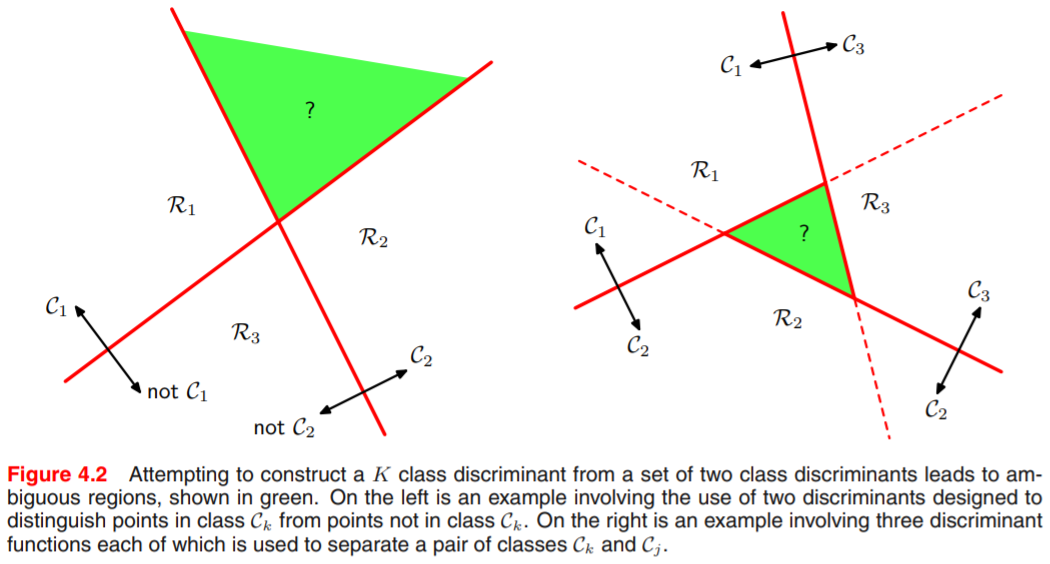

In [30]:
from IPython.display import Image
Image('figures/Figure4.2.png',width=700)
# Source: Bishop textbook

## Softmax Regression

We can avoid these difficulties by considering a **single $K$-class discriminant** comprising $K$ linear functions of the form

\begin{align*}
o_k(\mathbf{x}) = \mathbf{w}_k^T\mathbf{x} + b_k
\end{align*}

and then assigning a point $\mathbf{x}$ to class $C_k$ if $o_k(\mathbf{x}) > o_j(\mathbf{x})$ for all $j \neq k$. The decision
boundary between class $C_k$ and class $C_j$ is therefore given by $o_k(\mathbf{x}) = o_j(\mathbf{x})$ and hence corresponds to a $(D − 1)$-dimensional hyperplane defined by

\begin{align*}
(\mathbf{w}_k - \mathbf{w}_j)^T\mathbf{x} + (b_k - bj) = 0
\end{align*}

This has the same form as the decision boundary for the two-class case.

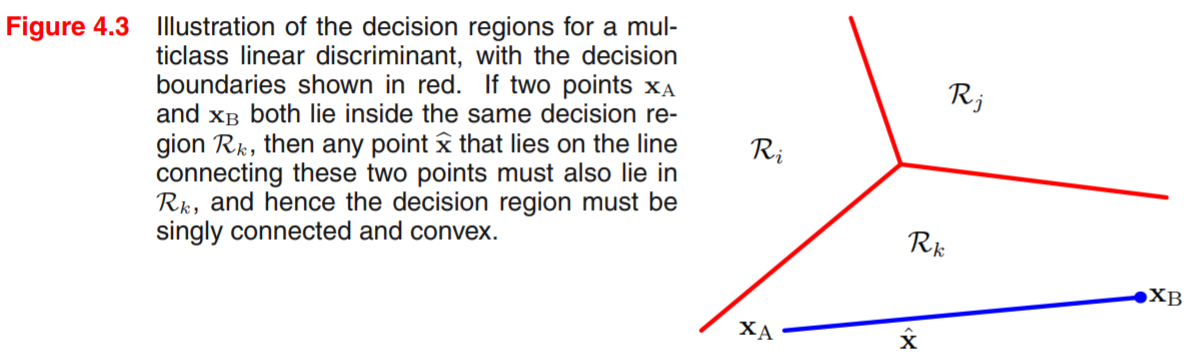

In [31]:
Image('figures/Figure4.3.png',width=800)
# Source: Bishop textbook

The decision regions of such a discriminant are always **singly connected** and **convex**.

Once you have computed the score of every class for the instance $\mathbf{x}$, i.e. $o_k(\mathbf{x})$, you can estimate the probability $p_k$ that the instance belongs to class $k$ by running the scores through the **softmax function**.

\begin{align*}
p_k = \frac{\exp(o_k(\mathbf{x}))}{\sum_{j=1}^K \exp(o_j(\mathbf{x}))}
\end{align*}

The function computes the exponential of every score, then normalizes them (dividing by the sum of all the exponentials). The scores are generally called logits or log-odds (although they are actually unnormalized log-odds).

The derivations will be derived in the same way as earlier (left as exercise).

In [32]:
# Let's consider now a 3-class classification problem

X = iris.data[:,2:]

t = iris.target

t

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [33]:
log_reg = LogisticRegression(multi_class='multinomial', penalty=None)

In [34]:
log_reg.fit(X, t)

C:\Users\aramirezsalgado\AppData\Local\anaconda3\envs\ramirez_env\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(multi_class='multinomial', penalty=None)

In [35]:
probs = log_reg.predict_proba(mesh)

probs

array([[1.00000000e+00, 3.97841014e-27, 2.49211395e-51],
       [1.00000000e+00, 4.38161225e-27, 2.90727108e-51],
       [1.00000000e+00, 4.82567791e-27, 3.39158855e-51],
       ...,
       [3.14691748e-59, 1.49712079e-14, 1.00000000e+00],
       [2.69753894e-59, 1.41339515e-14, 1.00000000e+00],
       [2.31233147e-59, 1.33435183e-14, 1.00000000e+00]])

In [36]:
pred = log_reg.predict(mesh)

pred

array([0, 0, 0, ..., 2, 2, 2])

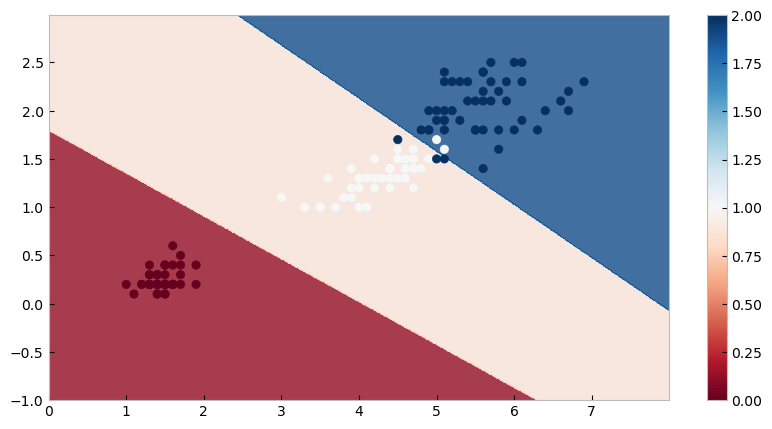

In [37]:
plt.figure(figsize=(10,5))
plt.contourf(xx, yy, pred.reshape(xx.shape), cmap=plt.cm.RdBu, alpha=.8)
plt.scatter(X[:,0], X[:,1], c=t, cmap=plt.cm.RdBu)
plt.rcParams['axes.grid'] = False #runtime configuration (rc) settings
plt.colorbar();

---

# MNIST Dataset

Let's consider another popular benchmark dataset: the MNIST dataset. The MNIST dataset is a set of 70,000 small images of digits handwritten by high school students and employees of the US Census Bureau.

In [38]:
from sklearn.datasets import fetch_openml 

mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')

mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [39]:
X, t = mnist.data, mnist.target

X.shape, t.shape

((70000, 784), (70000,))

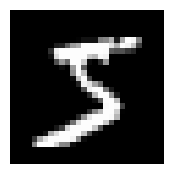

In [40]:
some_digit = X[0,:] #X[0]

some_digit_image = some_digit.reshape(28, 28) 

plt.figure(figsize=(2,2))
plt.imshow(some_digit_image, cmap='gray') 
plt.axis('off');

In [41]:
t[0]

'5'

Note that the label is a string.

In [42]:
t = t.astype(np.uint8)

In [43]:
t[0]

np.uint8(5)

Some other examples:

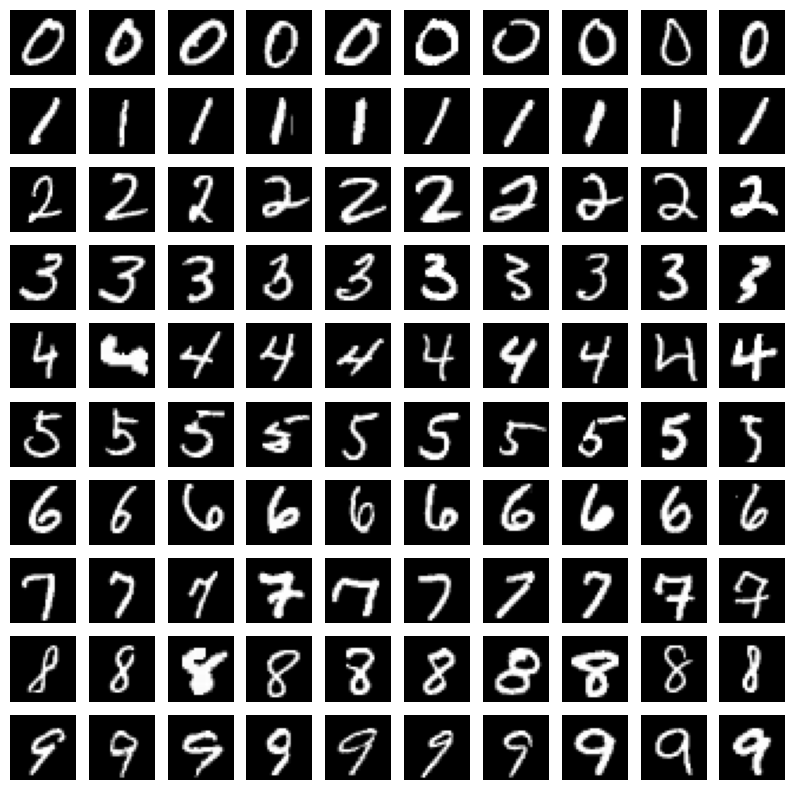

In [44]:
grid=1
plt.figure(figsize=(10,10))
for i in range(10):
    loc = np.where(t==i)[0]
    idx = np.random.permutation(range(len(loc)))
    for j in range(10):
        plt.subplot(10,10,grid)
        plt.imshow(X[loc[idx[j]],:].reshape(28,28), cmap='gray')
        plt.axis('off')
        grid+=1

Let's create our training and test sets:

In [45]:
# This is the standard train/test partition for the MNIST Dataset

X_train, X_test, t_train, t_test = X[:60000], X[60000:], t[:60000], t[60000:]

X_train.shape, X_test.shape, t_train.shape, t_test.shape

((60000, 784), (10000, 784), (60000,), (10000,))

In [46]:
from sklearn.preprocessing import MinMaxScaler

scaler=MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Let's start with a binary classifier to identify one digit - for example, digit 8. Call it the "8-detector":

In [48]:
t_train_8 = 1*(t_train == 8) 

t_test_8 = 1*(t_test == 8) # True for all 5s, False for all other digits

Training the logistic regression classifier:

In [49]:
log_reg = LogisticRegression(penalty=None,max_iter=200)

log_reg.fit(X_train, t_train_8)

LogisticRegression(max_iter=200, penalty=None)

In [50]:
log_reg.coef_.shape

(1, 784)

In [51]:
print('Accuracy Score in Training Set:', log_reg.score(X_train, t_train_8))
print('Accuracy Score in Test Set:', log_reg.score(X_test, t_test_8))

Accuracy Score in Training Set: 0.9620166666666666
Accuracy Score in Test Set: 0.9612


---
---
---

# Performance Measures for Classification Tasks

A key step in machine learning algorithm development and testing is determining a good error and evaluation metric.

**Evaluation metrics** help us to estimate how well our model is trained and it is important to pick a metric that matches our overall goal for the system.

Some common evaluation metrics include precision, recall, receiver operating curves, and confusion matrices.

## Measuring Accuracy using Cross-Validation

Classification accuracy and e the number of correct predictions made as a ratio of all predictions made.

* **Classification accuracy** is defined as the number of correctly classified samples divided by all samples:

\begin{align*}
\text{accuracy} = \frac{N_{\text{corr}}}{N}
\end{align*}

where $N_{\text{corr}}$ is the number of correct classified samples and $N$ is the total number of samples.

* **Classification error** is defined as the number of incorrectly classified samples divided by all samples:

\begin{align*}
\text{error} = \frac{N_{\text{miss}}}{N}
\end{align*}

where $N_{\text{miss}}$ is the number of misclassified samples and $N$ is the total number of samples.

* Classification accuracy is the most common evaluation metric for classification problems, it is also the most misused. It is really only suitable when there are an equal number of observations in each class (which is rarely the case) and that all predictions and prediction errors are equally important, which is often not the case.

In [52]:
from sklearn.model_selection import cross_val_score, KFold

cross_val_score(log_reg, X_train, t_train_8, 
                cv=KFold(10,shuffle=True,random_state=0), 
                scoring='accuracy')

array([0.95933333, 0.96033333, 0.95916667, 0.95866667, 0.95866667,
       0.96333333, 0.95766667, 0.95716667, 0.95333333, 0.95733333])

Looks good! But is it!?

Let's consider the case where we always predict "not-8":

In [ ]:
from sklearn.base import BaseEstimator 

class Never8Classifier (BaseEstimator): 
    def fit(self, X, y=None): 
        return self 
    def predict(self, X): 
        return np.zeros((len(X), 1))

In [ ]:
never_8_clf = Never8Classifier()

cross_val_score(never_8_clf, X_train, t_train_8, 
                cv=KFold(10,shuffle=True,random_state=0),
                scoring='accuracy')

It has over 90% accuracy! This is simply because only about 10% of the images are 8s, so if you always guess that an image is not a 5, you will be right about 90% of the time. 

This demonstrates why accuracy is generally not the preferred performance measure for classifiers, especially when you are dealing with skewed datasets (i.e., when some classes are much more frequent than others).

## Confusion Matrix

A confusion matrix summarizes the classification accuracy across several classes. It shows the ways in which the classification model is confused when it makes predictions, allowing visualization of the performance of our algorithm. 

Generally, each row represents the instances of a actual class while each column represents the instances in an predicted class.

All correct predictions are located in the diagonal of the table. So it is easy to visually inspect the table for prediction errors, as they will be represented by values outside the diagonal.

We are often looking to discriminate between observations with a specific binary outcome, for example, event or no event. In our example, we can assign the event (digit 8) as "positive" and no-event (not digit 8) as "negative".

The confusion matrix for this two-class classification problem is:

|actual/predict|    digit 8    |  not-digit-8  |
|--------------|--------------|--------------|
|    digit-8    |      100     |       0      |
|  non-digit-8  |       0      |      50      |

* **True positive (TP):** correctly predicting positive events
* **False positive (FP):** incorrectly calling positive to a negative event
* **True negative (TN):** correctly predicting negative events
* **False negative (FN):** incorrectly labeling negative to a positive event

*In this salmon/non-salmon classification problem, what are the TP, FP, TN, FN values?*

|actual/predict|   Positive   |   Negative   |
|--------------|--------------|--------------|
|   Positive   |      TP      |      FN      |
|   Negative   |      FP      |      TN      |

In [ ]:
from sklearn.model_selection import cross_val_predict 

y_train = cross_val_predict(log_reg, X_train, t_train_8, 
                            cv=KFold(10, shuffle=True, random_state=0))

In [ ]:
from sklearn.metrics import confusion_matrix

confusion_matrix(t_train_8, y_train)

Examples of each type of assessment:

In [ ]:
idx_tp = np.where((t_train_8==1)&(y_train==1))[0]

idx_tn = np.where((t_train_8==0)&(y_train==0))[0]

idx_fp = np.where((t_train_8==0)&(y_train==1))[0]

idx_fn = np.where((t_train_8==1)&(y_train==0))[0]

idx = np.vstack((idx_tp[:10], idx_tn[:10], idx_fp[:10], idx_fn[:10]))
idx.shape

In [ ]:
plt.figure(figsize=(15,7))
labels=['TP','TN','FP','FN']
grid=1
for i in range(4):
    for j in range(10):
        plt.subplot(4,10,grid)
        plt.imshow(X_train[idx[i,j],:].reshape(28,28), cmap='gray')
        plt.axis('off')
        plt.title(labels[i])
        grid+=1

---

# Precision, Recall & Fall-Out

* **Precision**, also called Positive Predictive Value (PPV), is the performance of detection

\begin{align*}
\text{Precision} = \text{PPV} = \frac{TP}{TP + FP}
\end{align*}

* **Recall**, also called True Positive Rate (TPR) or Sensitivity, is the probability of detection

\begin{align*}
\text{Recall} = \text{TPR} = \text{Sensitivity} = \frac{TP}{TP + FN}
\end{align*}

* **Fall-out**, also called False Positive Rate (FPR), is the probability of false alarm

\begin{align*}
\text{Fall-out} = \text{FPR} = \frac{FP}{FP + TN}
\end{align*}

* **Specificity**, also called True Negative Rate (TNR), is the probability of negative events detection

\begin{align*}
\text{Specificity} = \frac{TN}{TN + FP}
\end{align*}

* **F1-score**, also called F-score or F-measure, is a measure of a model's accuracy. It considers both the precision and the recall.

\begin{align*}
\text{F1-score} = 2\times\frac{\text{Precision}\times \text{Recall}}{\text{Precision} + \text{Recall}}
\end{align*}

* Learn about many other measures on this [Wikipedia page](https://en.wikipedia.org/wiki/Sensitivity_and_specificity) and [Scikit-Learn's Classification Metrics Module](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.metrics).

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [ ]:
precision_score(t_train_8, y_train)

In [ ]:
recall_score(t_train_8, y_train)

In [ ]:
f1_score(t_train_8, y_train)

The F1 score favors classifiers that have similar precision and recall. Unfortunately, you can't have it both ways: increasing precision reduces recall, and vice versa. This is called the **precision/recall trade-off**.

---